<div style="background: white;
            padding: 30px 35px;
            border-radius: 8px;
            border-left: 6px solid #2d6a4f;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;">

<h1 style="margin-bottom: 5px;">NB01: Data Collection & Inspection</h1>

<p style="font-weight: bold; margin-top: 0;">Credit Default Prediction · IFRS 9 Provisioning Model · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 12th April 2026</li>
    <li>🎯 <strong>Purpose:</strong> Download the German Credit dataset, inspect its structure, understand each feature, and save a clean version ready for exploratory analysis in NB02</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li>German Credit dataset via UCI Machine Learning Repository</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/raw/german_credit_raw.csv</code> — original dataset as downloaded</li>
    <li><code>../data/processed/german_credit_clean.csv</code> — renamed columns, binary target, clean types</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Dataset download via <code>urllib</code></li>
    <li>Column renaming and type inspection</li>
    <li>Missing value checks</li>
    <li>Target variable encoding</li>
    <li>Class balance check</li>
    <li>Feature dictionary — understanding what each column means</li>
</ul>

<p><strong>Workflow:</strong> Download → Inspect Structure → Rename Columns → Check Missing Values → Encode Target → Check Class Balance → Save</p>

</div>

## ⚙️ Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import warnings
from sklearn.datasets import fetch_openml

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📥 Section 1: Download the Dataset

### 📍 Step 1: Download German Credit Data from UCI Repository

The German Credit dataset is a classic benchmark dataset for credit risk modelling.
It contains 1,000 loan applicants described by 20 features — a mix of financial,
demographic, and loan characteristics. Each applicant is labelled as a good credit
risk (repaid) or bad credit risk (defaulted).

We download it directly from the UCI Machine Learning Repository, which hosts the
original data exactly as used in academic research.

In [24]:
RAW_PATH = "../data/raw/german_credit_raw.csv"

print("⏳ Downloading German Credit dataset via OpenML...")

data = fetch_openml(name="credit-g", version=1, as_frame=True, parser="auto")

# Combine features + target into one dataframe
df_raw = data.frame.copy()
df_raw["target"] = data.target.values

df_raw.to_csv(RAW_PATH, index=False)

print(f"✅ Downloaded and saved to {RAW_PATH}")
print(f"📐 Shape  : {df_raw.shape}")
print(f"📋 Columns: {df_raw.columns.tolist()}")

⏳ Downloading German Credit dataset via OpenML...
✅ Downloaded and saved to ../data/raw/german_credit_raw.csv
📐 Shape  : (1000, 22)
📋 Columns: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class', 'target']


### 📍 Step 2: Load and Preview Raw Data

In [25]:
df_raw = pd.read_csv(RAW_PATH)

print(f"✅ Raw data loaded")
print(f"📐 Shape : {df_raw.shape} (rows = applicants, cols = features + target)")
print(f"\n🔍 First 5 rows:")
df_raw.head()

✅ Raw data loaded
📐 Shape : (1000, 22) (rows = applicants, cols = features + target)

🔍 First 5 rows:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,67,none,own,2,skilled,1,yes,yes,good,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,22,none,own,1,skilled,1,none,yes,bad,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,49,none,own,1,unskilled resident,2,none,yes,good,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,45,none,for free,1,skilled,2,none,yes,good,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,53,none,for free,2,skilled,2,none,yes,bad,bad


## 🏷️ Section 2: Rename Columns

### 📍 Step 3: Apply Human-Readable Column Names

The OpenML version already provides readable column names, but uses slightly
different naming conventions. We standardise all column names for consistency
across the project and drop the duplicate target column introduced during download.

Below is the full feature dictionary explaining what each column represents:

| Column | Name | Description |
|--------|------|-------------|
| checking_account | checking_account | Status of existing checking account |
| duration | duration | Loan duration in months |
| credit_history | credit_history | Past credit history |
| purpose | purpose | Purpose of the loan |
| credit_amount | credit_amount | Loan amount in DM (Deutschmarks) |
| savings_account | savings_account | Savings account / bonds balance |
| employment | employment | Years in current employment |
| installment_rate | installment_rate | Instalment rate as % of disposable income |
| personal_status | personal_status | Personal status and sex |
| other_debtors | other_debtors | Other debtors / guarantors |
| residence_since | residence_since | Years at current residence |
| property | property | Most valuable property owned |
| age | age | Age in years |
| other_installments | other_installments | Other instalment plans |
| housing | housing | Housing situation |
| existing_credits | existing_credits | Number of existing credits at this bank |
| job | job | Job type / skill level |
| dependents | dependents | Number of people financially dependent |
| telephone | telephone | Telephone registered in applicant's name |
| foreign_worker | foreign_worker | Whether applicant is a foreign worker |
| target | target | 0 = repaid (good), 1 = defaulted (bad) |

In [26]:
# Drop duplicate target column and rename for consistency
df = df_raw.drop(columns=["target"]).copy()

df = df.rename(columns={
    "checking_status"        : "checking_account",
    "savings_status"         : "savings_account",
    "installment_commitment" : "installment_rate",
    "other_parties"          : "other_debtors",
    "property_magnitude"     : "property",
    "other_payment_plans"    : "other_installments",
    "num_dependents"         : "dependents",
    "own_telephone"          : "telephone",
    "class"                  : "target"
})

print("✅ Columns cleaned and renamed")
print(f"📐 Shape: {df.shape}")
print(f"\n📋 Final column names:")
print(df.columns.tolist())
df.head()

✅ Columns cleaned and renamed
📐 Shape: (1000, 21)

📋 Final column names:
['checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment', 'installment_rate', 'personal_status', 'other_debtors', 'residence_since', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'target']


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 🔍 Section 3: Inspect Data Structure

### 📍 Step 1: Data Types and Basic Info

In [27]:
print("📋 Data types and non-null counts:")
print(df.info())

📋 Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   checking_account    1000 non-null   object
 1   duration            1000 non-null   int64 
 2   credit_history      1000 non-null   object
 3   purpose             1000 non-null   object
 4   credit_amount       1000 non-null   int64 
 5   savings_account     1000 non-null   object
 6   employment          1000 non-null   object
 7   installment_rate    1000 non-null   int64 
 8   personal_status     1000 non-null   object
 9   other_debtors       1000 non-null   object
 10  residence_since     1000 non-null   int64 
 11  property            1000 non-null   object
 12  age                 1000 non-null   int64 
 13  other_installments  1000 non-null   object
 14  housing             1000 non-null   object
 15  existing_credits    1000 non-null   int

### 📍 Step 2: Check for Missing Values

In [28]:
missing = df.isnull().sum()
print("🔍 Missing values per column:")
print(missing)
print(f"\n✅ Total missing values: {missing.sum()}")

🔍 Missing values per column:
checking_account      0
duration              0
credit_history        0
purpose               0
credit_amount         0
savings_account       0
employment            0
installment_rate      0
personal_status       0
other_debtors         0
residence_since       0
property              0
age                   0
other_installments    0
housing               0
existing_credits      0
job                   0
dependents            0
telephone             0
foreign_worker        0
target                0
dtype: int64

✅ Total missing values: 0


### 📍 Step 3: Summary Statistics for Numerical Features

In [29]:
numerical_cols = ["duration", "credit_amount", "installment_rate",
                  "residence_since", "age", "existing_credits", "dependents"]

print("📊 Summary statistics for numerical features:")
df[numerical_cols].describe().round(2)

📊 Summary statistics for numerical features:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


## 🎯 Section 4: Encode Target Variable

### 📍 Convert Target to Binary (0/1)

In the raw dataset the target is coded as:
- **1** = good credit risk (borrower repaid)
- **2** = bad credit risk (borrower defaulted)

We recode this to the standard binary convention used in all classification
models: **0 = repaid (good), 1 = defaulted (bad)**. This means our model will
predict the probability of default directly, which is the natural framing for
credit risk — we want to know the chance of the bad outcome.

In [30]:
print("🔍 Raw target values:")
print(df["target"].value_counts())

# Recode: 'good' → 0 (repaid), 'bad' → 1 (defaulted)
df["target"] = df["target"].map({"good": 0, "bad": 1})

print("\n✅ Target variable recoded:")
print("   0 = good credit risk (repaid)")
print("   1 = bad credit risk (defaulted)")
print(f"\n📊 Target distribution after recoding:")
print(df["target"].value_counts())

🔍 Raw target values:
target
good    700
bad     300
Name: count, dtype: int64

✅ Target variable recoded:
   0 = good credit risk (repaid)
   1 = bad credit risk (defaulted)

📊 Target distribution after recoding:
target
0    700
1    300
Name: count, dtype: int64


## ⚖️ Section 5: Class Balance Check

### 📍 Visualise Class Balance

Class imbalance is one of the most important things to check before building
any classification model. If 95% of borrowers repaid and only 5% defaulted,
a model that simply predicts "repaid" for everyone would be 95% accurate —
but completely useless for the actual task of identifying defaulters.

Understanding the class balance upfront shapes every subsequent modelling
decision: choice of evaluation metric, whether to resample the data, and
how to interpret results.

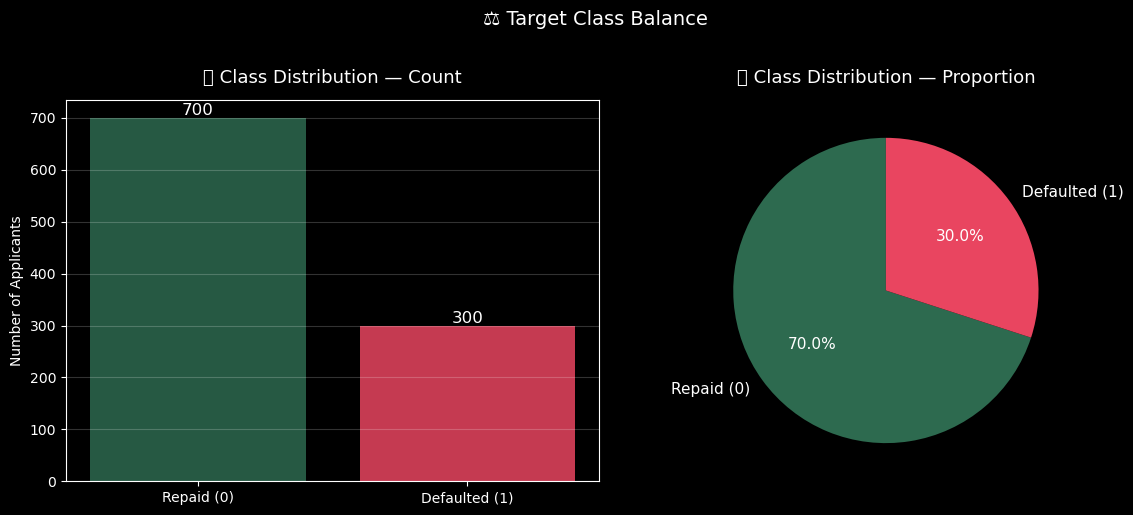

💾 Saved to ../figures/class_balance.png


In [31]:
counts = df["target"].value_counts().sort_index()
labels = ["Repaid (0)", "Defaulted (1)"]
colors = ["#2d6a4f", "#e94560"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor="none", alpha=0.85)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=12, color="white")
axes[0].set_title("📊 Class Distribution — Count", fontsize=13, pad=12)
axes[0].set_ylabel("Number of Applicants")
axes[0].grid(alpha=0.2, axis="y")

# Pie chart
axes[1].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"color": "white", "fontsize": 11}
)
axes[1].set_title("📊 Class Distribution — Proportion", fontsize=13, pad=12)

plt.suptitle("⚖️ Target Class Balance", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/class_balance.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/class_balance.png")

## 📊 Section 6: Feature Overview

### 📍 Step 1: Categorical Feature Value Counts

The dataset contains categorical features with string values describing
borrower characteristics. Here we inspect the unique values in each
categorical column so we understand the range of categories before
transforming them in NB02.

In [32]:
categorical_cols = [
    "checking_account", "credit_history", "purpose", "savings_account",
    "employment", "personal_status", "other_debtors", "property",
    "other_installments", "housing", "job", "telephone", "foreign_worker"
]

print("📋 Unique values per categorical feature:\n")
for col in categorical_cols:
    print(f"  {col}: {sorted(df[col].unique().tolist())}")

📋 Unique values per categorical feature:

  checking_account: ['0<=X<200', '<0', '>=200', 'no checking']
  credit_history: ['all paid', 'critical/other existing credit', 'delayed previously', 'existing paid', 'no credits/all paid']
  purpose: ['business', 'domestic appliance', 'education', 'furniture/equipment', 'new car', 'other', 'radio/tv', 'repairs', 'retraining', 'used car']
  savings_account: ['100<=X<500', '500<=X<1000', '<100', '>=1000', 'no known savings']
  employment: ['1<=X<4', '4<=X<7', '<1', '>=7', 'unemployed']
  personal_status: ['female div/dep/mar', 'male div/sep', 'male mar/wid', 'male single']
  other_debtors: ['co applicant', 'guarantor', 'none']
  property: ['car', 'life insurance', 'no known property', 'real estate']
  other_installments: ['bank', 'none', 'stores']
  housing: ['for free', 'own', 'rent']
  job: ['high qualif/self emp/mgmt', 'skilled', 'unemp/unskilled non res', 'unskilled resident']
  telephone: ['none', 'yes']
  foreign_worker: ['no', 'yes']


### 📍 Step 2: Distribution of Key Numerical Features

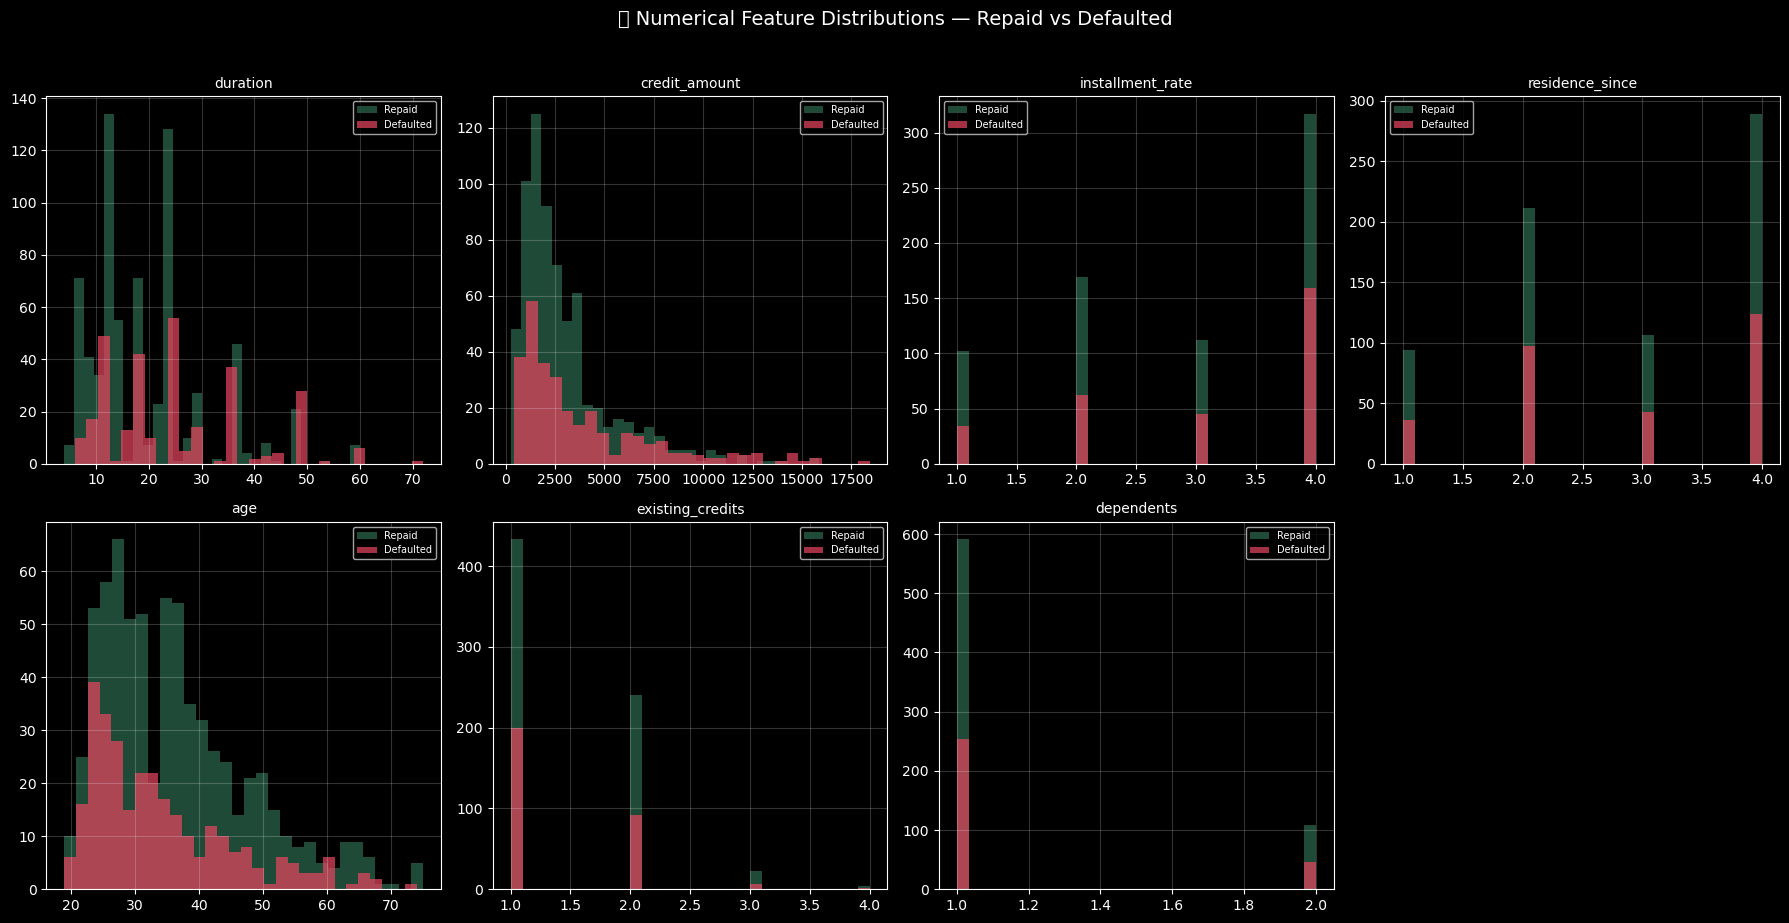

💾 Saved to ../figures/numerical_distributions.png


In [33]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[df["target"]==0][col], bins=30, alpha=0.7,
                 color="#2d6a4f", label="Repaid", edgecolor="none")
    axes[i].hist(df[df["target"]==1][col], bins=30, alpha=0.7,
                 color="#e94560", label="Defaulted", edgecolor="none")
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.2)

axes[-1].set_visible(False)
fig.suptitle("📊 Numerical Feature Distributions — Repaid vs Defaulted",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/numerical_distributions.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/numerical_distributions.png")

## 💾 Section 7: Save Cleaned Data

### 📍 Save to CSV

In [34]:
PROCESSED_PATH = "../data/processed/german_credit_clean.csv"
df.to_csv(PROCESSED_PATH, index=False)

print("✅ Files saved:")
print(f"   📄 ../data/raw/german_credit_raw.csv")
print(f"   📄 {PROCESSED_PATH}")
print(f"\n📐 Final dataset shape : {df.shape}")
print(f"🎯 Target distribution  : {df['target'].value_counts().to_dict()}")
print(f"\n🚀 Ready for NB02 — Exploratory Data Analysis")

✅ Files saved:
   📄 ../data/raw/german_credit_raw.csv
   📄 ../data/processed/german_credit_clean.csv

📐 Final dataset shape : (1000, 21)
🎯 Target distribution  : {0: 700, 1: 300}

🚀 Ready for NB02 — Exploratory Data Analysis


In [35]:
# Display the data
pd.read_csv("../data/processed/german_credit_clean.csv").head(10)

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,0
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,1
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,0
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,1
5,no checking,36,existing paid,education,9055,no known savings,1<=X<4,2,male single,none,...,no known property,35,none,for free,1,unskilled resident,2,yes,yes,0
6,no checking,24,existing paid,furniture/equipment,2835,500<=X<1000,>=7,3,male single,none,...,life insurance,53,none,own,1,skilled,1,none,yes,0
7,0<=X<200,36,existing paid,used car,6948,<100,1<=X<4,2,male single,none,...,car,35,none,rent,1,high qualif/self emp/mgmt,1,yes,yes,0
8,no checking,12,existing paid,radio/tv,3059,>=1000,4<=X<7,2,male div/sep,none,...,real estate,61,none,own,1,unskilled resident,1,none,yes,0
9,0<=X<200,30,critical/other existing credit,new car,5234,<100,unemployed,4,male mar/wid,none,...,car,28,none,own,2,high qualif/self emp/mgmt,1,none,yes,1


## 🪞 Personal Reflection Notes — NB01

**🎯 Key Decisions Made in This Notebook**

The first decision was dataset selection. I chose the German Credit dataset over
the Lending Club dataset for two reasons. First, at 1,000 observations it is small
enough to be computationally manageable while still being large enough to train and
evaluate classification models meaningfully. Second, it is a widely used academic
benchmark, which means the modelling choices I make can be compared against
published results — a useful sanity check when evaluating model performance in NB03
and NB04.

The second decision was how to handle the download. The UCI repository returned a
502 error when accessed directly via urllib, so I switched to scikit-learn's
fetch_openml interface, which provides the same dataset via a more reliable mirror.
The OpenML version came with readable column names already attached, which meant
the renaming step was a light standardisation exercise rather than a full mapping
from scratch. I also discovered that the download produced a duplicate target column
— one from the original dataframe and one I added manually — which required dropping
one before proceeding.

The third decision was target encoding. The raw target was coded as strings —
"good" and "bad" — rather than the numeric 1/2 convention of the original UCI
file. I recoded these to 0 (repaid) and 1 (defaulted), which is the standard
binary convention for classification models. Encoding default as 1 means the model
directly outputs the probability of the bad outcome, which is the natural framing
for credit risk — a loan officer wants to know the chance of non-repayment, not the
chance of repayment.

---

**📊 What the Charts Revealed**

The class balance chart showed a 70/30 split — 700 repaid borrowers versus 300
defaulters. This is a moderately imbalanced dataset. It is not severe enough to
require aggressive resampling techniques like SMOTE, but it is imbalanced enough
that accuracy alone will be a misleading evaluation metric in NB03 and NB04. A
model that predicts "repaid" for every applicant would achieve 70% accuracy while
identifying zero defaulters — which is commercially useless. This is why I will
prioritise ROC-AUC and precision-recall over accuracy when evaluating models. The
30% default rate is also notably higher than real-world default rates, which
typically sit between 2-10% depending on the loan type — this dataset was
deliberately constructed with a higher default rate to make the classification
problem tractable for research purposes.

The numerical feature distributions revealed several patterns that I expect to be
predictive of default. Duration shows a clear separation — defaulters tend to have
longer loan durations, with the defaulted distribution skewing further right than
the repaid distribution. This makes intuitive sense: a longer loan means more time
for circumstances to change and for a borrower's financial situation to deteriorate.
Credit amount shows a similar pattern — defaulters cluster at higher loan amounts,
which reflects the higher repayment burden associated with larger loans.

Age showed the most interesting separation. Younger borrowers (roughly 20-35)
have a noticeably higher proportion of defaulters relative to repaid, while the
defaulted distribution thins out sharply after age 40. This likely reflects the
financial instability of early career stages — lower income, less savings, less
established credit history — all of which make younger borrowers structurally
riskier. This is a well-documented pattern in real credit risk literature and gives
me confidence that the dataset reflects genuine credit behaviour rather than being
purely synthetic.

Installment rate and residence since both showed limited visual separation between
defaulted and repaid distributions, suggesting they may be weaker predictors
individually. Existing credits and dependents were heavily concentrated at a small
number of discrete values (1-4 credits, 1-2 dependents) — they are better treated
as ordinal categorical variables than continuous ones, which is something to address
in NB02's feature engineering step.

---

**🔜 What This Sets Up for NB02**

The key priorities going into NB02 are feature engineering and encoding. The
categorical columns currently contain string values describing borrower
characteristics — these need to be converted into numerical form before any model
can use them. The patterns observed in the numerical distributions — particularly
duration, credit amount, and age — suggest these will be among the most predictive
features, and I want to explore them more rigorously through correlation analysis
and grouped statistics in NB02 before building any models.